In [8]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [9]:
import pickle
with open("/kaggle/input/datasets/ashura369/my-dataset/df_1.kl", "rb") as f:
    data = pickle.load(f)

In [10]:
data.sample(6)

,id,name,date,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
723,570121588487663616,FIETA_DOC,2015-02-23,Monday,23,Central_Time,United,this will definitely be a trip to remember EWR...,Late Flight,0.434652,0,positive
14585,569595595754639360,SchrierCar,2015-02-22,Sunday,12,Atlantic_Time_(Canada),American,"no hold times, just disconnections. There is...",Customer Service Issue,0.648000,0,negative
7258,569723086465069056,castellarin1126,2015-02-22,Sunday,20,Eastern_Time,Delta,other jfk to Boston flights went off with some...,Cancelled Flight,0.347400,0,negative
9310,569989745503297536,SLKToday,2015-02-23,Monday,14,Eastern_Time,US_Airways,why are your customer service department so in...,Customer Service Issue,1.000000,0,negative
7954,568931762518110208,KTrerotola,2015-02-20,Friday,16,Eastern_Time,Delta,thanks! I only loose 'em at airports...1st tim...,Customer Service Issue,0.000000,0,neutral
5901,568496176116457472,funnyfellah,2015-02-19,Thursday,11,Central_Time,Southwest,can't DM you without you following me...,Customer Service Issue,0.344400,0,negative


# Dropping useless columns

In [11]:
data = data.drop(columns=['id', 'name','date'])

# Doing Lemmatization

In [12]:
!pip install cleantext

In [13]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words =  stopwords.words('english')

from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()

from cleantext import clean

import re
import emoji

In [14]:
def transform(txt):
    txt = clean(txt,lowercase=True,punct=True)    
    txt = re.sub(r'(.)\1{2,}', r'\1', txt)              
    txt = re.sub(r'https?://\S+|www\.\S+', '', txt)    
    txt = re.sub(r'@\S+', '', txt)                     
    txt = emoji.demojize(txt)                           
    txt = word_tokenize(txt)
                       
    temp = [lmt.lemmatize(word, pos='v') for word in txt if word not in stop_words and (word.isalpha() or (word.startswith(':') and word.endswith(':')))]
                        
    temp2 = temp[:]
    temp2 = " ".join(temp)
    return temp2


In [15]:
transform('Hello my name is Pradhan.')

'hello name pradhan'

# Putting all the text based features into one feature

In [16]:
data['text'] = data[['day_name','timezone','airlines','feedback','reason']].astype(str).agg(" ".join, axis=1)

In [17]:
data = data[['hour','reason_confidence','retweets','text','sentiment']]

In [18]:
data.head(6)

,hour,reason_confidence,retweets,text,sentiment
0,11,0.0000,0,Tuesday Eastern_Time Virgin_America What said....,neutral
1,11,0.0000,0,Tuesday Pacific_Time Virgin_America plus you'v...,positive
2,11,0.0000,0,Tuesday Central_Time Virgin_America I didn't t...,neutral
3,11,0.7033,0,Tuesday Pacific_Time Virgin_America it's reall...,negative
4,11,1.0000,0,Tuesday Pacific_Time Virgin_America and it's a...,negative
5,11,0.6842,0,Tuesday Pacific_Time Virgin_America seriously ...,negative


In [19]:
x = data.drop(columns=['sentiment'])
y = data['sentiment']

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

# Using `LabelEncoder` on sentiment

In [21]:
le = LabelEncoder()
y = le.fit_transform(y)

In [22]:
y

array([1, 2, 1, ..., 1, 0, 1], shape=(14640,))

# Before doing Scaling on numerical data first, we have to apply the lemmatization

In [23]:
x['text_transformed'] = x['text'].apply(transform)

In [24]:
x.head(6)

,hour,reason_confidence,retweets,text,text_transformed
0,11,0.0000,0,Tuesday Eastern_Time Virgin_America What said....,tuesday easterntime virginamerica say flight b...
1,11,0.0000,0,Tuesday Pacific_Time Virgin_America plus you'v...,tuesday pacifictime virginamerica plus youve a...
2,11,0.0000,0,Tuesday Central_Time Virgin_America I didn't t...,tuesday centraltime virginamerica didnt today ...
3,11,0.7033,0,Tuesday Pacific_Time Virgin_America it's reall...,tuesday pacifictime virginamerica really aggre...
4,11,1.0000,0,Tuesday Pacific_Time Virgin_America and it's a...,tuesday pacifictime virginamerica really big b...
5,11,0.6842,0,Tuesday Pacific_Time Virgin_America seriously ...,tuesday pacifictime virginamerica seriously wo...


## Using `MinMaxScaler` on hour, and `StandardScaler` on reason_confidence, and retweets

In [25]:
processor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), ['hour']),
        ('standard', StandardScaler(), ['reason_confidence','retweets']),
    ], remainder='drop'
)

In [26]:
temp = processor.fit_transform(x)

In [27]:
x[['hour','reason_confidence','retweets']] = pd.DataFrame(temp, columns=['hour','reason_confidence','retweets'])

In [28]:
x = x.drop(columns='text')
x.head(6)

,hour,reason_confidence,retweets,text_transformed
0,0.478261,-1.208684,-0.110828,tuesday easterntime virginamerica say flight b...
1,0.478261,-1.208684,-0.110828,tuesday pacifictime virginamerica plus youve a...
2,0.478261,-1.208684,-0.110828,tuesday centraltime virginamerica didnt today ...
3,0.478261,0.585982,-0.110828,tuesday pacifictime virginamerica really aggre...
4,0.478261,1.343095,-0.110828,tuesday pacifictime virginamerica really big b...
5,0.478261,0.537243,-0.110828,tuesday pacifictime virginamerica seriously wo...


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=4000, sublinear_tf=True)


In [30]:
temp = tfidf.fit_transform(x['text_transformed'])

In [31]:
# print(temp))
temp.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(14640, 2882))

In [32]:
print(tfidf.get_feature_names_out().tolist())

['aa', 'aa customer', 'aadvantage', 'able', 'able get', 'absolute', 'absolutely', 'absurd', 'abudhabi', 'abudhabi usairways', 'accept', 'acceptable', 'access', 'accommodate', 'accord', 'account', 'acct', 'accurate', 'across', 'act', 'action', 'actual', 'actually', 'add', 'additional', 'address', 'admirals', 'admirals club', 'advance', 'advantage', 'advertise', 'advise', 'advisory', 'affect', 'afford', 'afternoon', 'age', 'agent', 'agents', 'ago', 'ah', 'ahead', 'air', 'air customer', 'aircraft', 'airfare', 'airline', 'airline cancel', 'airline cant', 'airline customer', 'airline ever', 'airline flight', 'airlines', 'airlines cant', 'airlines customer', 'airplane', 'airport', 'airport cant', 'airport customer', 'airport flight', 'airports', 'airways', 'alaska', 'alaska american', 'alaska delta', 'alaska southwest', 'alaska unite', 'alaska usairways', 'alert', 'alist', 'allow', 'almost', 'almost hour', 'almost hours', 'alone', 'along', 'already', 'already cancel', 'also', 'alternate', 'a

In [33]:
x.columns

Index(['hour', 'reason_confidence', 'retweets', 'text_transformed'], dtype='object')

In [34]:
temp2 = pd.DataFrame(temp.toarray(), columns=[f"tfidf_{col}" for col in tfidf.get_feature_names_out()])
x_final = pd.concat([x[['hour','reason_confidence','retweets']], temp2], axis=1)
print(x_final.shape)
x_final.head(6)


(14640, 2885)


,hour,reason_confidence,retweets,tfidf_aa,tfidf_aa customer,tfidf_aadvantage,tfidf_able,tfidf_able get,tfidf_absolute,tfidf_absolutely,...,tfidf_york,tfidf_youd,tfidf_youll,tfidf_youre,tfidf_youre go,tfidf_youve,tfidf_yr,tfidf_yyz,tfidf_zero,tfidf_zone
0,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.411575,0.0,0.0,0.0,0.0
2,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.478261,0.585982,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.478261,1.343095,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,0.478261,0.537243,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [35]:
from sklearn.model_selection import train_test_split as ttt

x_train, x_test, y_train, y_test = ttt(x_final, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)

(11712, 2885)
(2928, 2885)


# Using `optuna` to train models like `xgboost`, `lightgbm`, `catboost`

In [39]:
import optuna
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

In [40]:
def model(trial):
    # choosing the model name
    model_name = trial.suggest_categorical('classifier', ['XGBClassifier', 'LGBMClassifier', 'CatBoostClassifier'])

    # doing train test split for training the model
    x_tr, x_val, y_tr, y_val = ttt(x_train, y_train, test_size=0.2, random_state=42)

    # setting the parameters globally for all models
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 12)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)

    # XGBClassifier
    if model_name == 'XGBClassifier':
        clf = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            objective='multi:softprob',
            learning_rate=learning_rate,
            random_state=42,
            early_stopping_rounds=10,
            tree_method='hist',
            device='cuda'
        )
        
        clf.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], verbose=False)

    # LGBMClassifier
    elif model_name == 'LGBMClassifier':
        num_leaves = trial.suggest_int('lgb_num_leaves', 8, 256)
        clf = LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            objective='multiclass',
            boosting_type='gbdt',
            num_leaves=num_leaves,
            random_state=42,
            verbosity=-1,
            device='gpu'
        )
        
        clf.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

    # CatBoostClassifier
    elif model_name == 'CatBoostClassifier':
        depth = trial.suggest_int('cat_depth', 3, 10)
        clf = CatBoostClassifier(
            iterations=n_estimators,
            depth=depth,
            learning_rate=learning_rate,
            random_state=42,
            verbose=False,
            early_stopping_rounds=10,
            task_type='GPU'
        )
        
        clf.fit(x_tr, y_tr, eval_set=(x_val, y_val), verbose=False)
        
    prediction = clf.predict(x_val)
    return accuracy_score(y_val, prediction)


In [41]:
study = optuna.create_study(direction='maximize')
study.optimize(model, n_trials=30)

[I 2026-05-27 18:19:37,172] A new study created in memory with name: no-name-70ff758b-5d81-4a26-948e-e38e1376be0b
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
[I 2026-05-27 18:19:56,025] Trial 0 finished with value: 0.9001280409731114 and parameters: {'classifier': 'LGBMClassifier', 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.015269163804

#### As we can see above the best accuracy is at **Trial 19** giving **0.93 (93 %)**.

In [42]:
print(f"BEST PARAMETERS :\n{study.best_params}")

BEST PARAMETERS :
{'classifier': 'XGBClassifier', 'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.09946886463918475}


# Choosing the Best Parameters and Best Model

We can also directly make the model for `XGBClassifier` and put all the parameters, but doing so will not be optimized, coz if we deploy the model on the server, and have to do model training again based on the new data received, we cant always manually write the final model. So we need to write it in a optimized way.

In [44]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [45]:
best_params = study.best_params.copy()
best_model = study.best_params.pop('classifier')       # storing the best model in the obj 'best_model'


final_params = {
    'learning_rate':best_params.get('learning_rate'),
    'random_state':42
}

if best_model == 'XGBClassifier':
    final_params['n_estimators'] = best_params.get('n_estimators')
    final_params['max_depth'] = best_params.get('max_depth')
    final_params['objective'] = 'multi:softprob'
    final_params['tree_method'] = 'hist'
    final_params['device'] = 'cuda'
    
    final_model = XGBClassifier(**final_params)

elif best_model == 'LGBMClassifier':
    final_params['n_estimators'] = best_params.get('n_estimators')
    final_params['max_depth'] = best_params.get('max_depth')
    final_params['num_leaves'] = best_params.get('lgb_num_leaves')
    final_params['objective'] = 'multiclass'
    final_params['boosting_type'] = 'gbdt'
    final_params['verbosity'] = -1
    final_params['device'] = 'gpu'
    
    final_model = LGBMClassifier(**final_params)
    
elif best_model == 'CatBoostClassifier':
    final_params['iterations'] = best_params.get('n_estimators')
    final_params['depth'] = best_params.get('cat_depth')
    final_params['verbose'] = False
    final_params['task_type'] = 'GPU'
    
    final_model = CatBoostClassifier(**final_params)

In [46]:
final_model.fit(x_train, y_train)
prediction = final_model.predict(x_test)

# Checking for accuracy at different parameters

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print(f"ACCURACY SCORE : \n{accuracy_score(y_test, prediction)}\n")
print(f"PRECISION SCORE : \n{precision_score(y_test, prediction, average='weighted')}\n")
print(f"RECALL SCORE : \n{recall_score(y_test, prediction, average='weighted')}\n")
print(f"CONFUSION MATRIX : \n{confusion_matrix(y_test, prediction)}")

ACCURACY SCORE : 
0.9310109289617486

PRECISION SCORE : 
0.9301735155299714

RECALL SCORE : 
0.9310109289617486

CONFUSION MATRIX : 
[[1887    0    2]
 [   2  512   66]
 [  18  114  327]]


# Plotting the `Confusion Matrix`

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

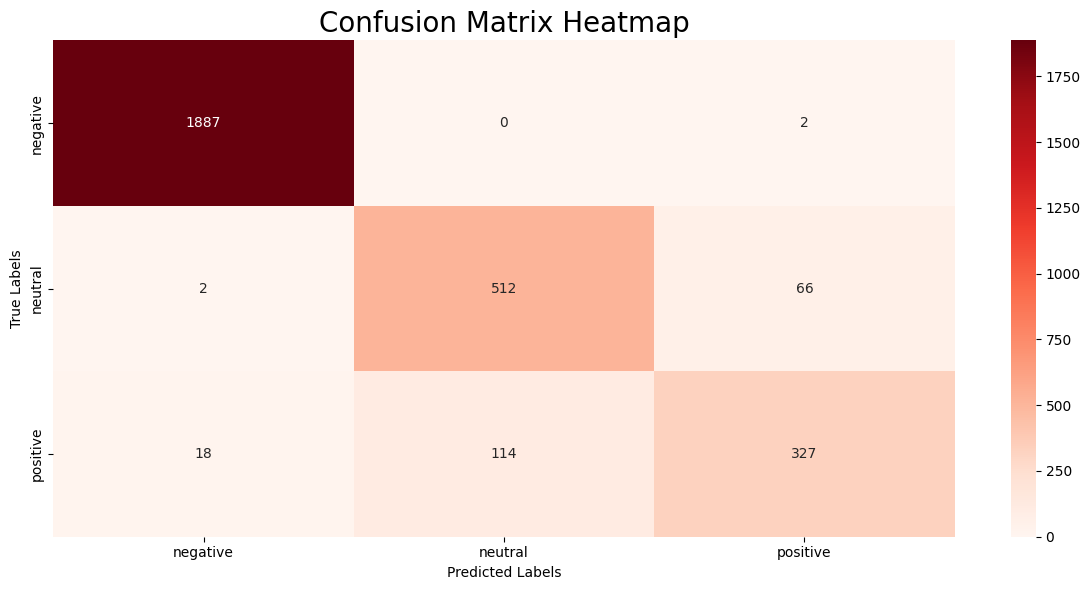

In [49]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap', fontsize=20)
plt.tight_layout()
plt.show()